# 15 — Walk-Forward ML Challenger vs Baseline Robot vs BIST100

Bu notebook ayrı ve dürüst bir ML karşılaştırması üretir.

**Neden başlangıç 2025?**

`Big_Winner_Label_2R`, Logistic Regression ve Q40 filtresi 2018–2024
araştırmasıyla seçildi. Bunları 2018'e geri uygulayıp tam dönem grafik
oluşturmak seçim yanlılığı yaratır. Bu nedenle karşılaştırma 2025'te başlar.

**Walk-forward akışı**

- Her ayın başında model yeniden eğitilir.
- Yalnızca o tarihten önce sinyali oluşmuş ve 5 günlük embargo öncesinde
  kapanmış işlemler eğitime girer.
- Model tipi ve Q40 eşiği değiştirilmez.
- Ay içindeki günlük Robot AL satırları yeni modelle skorlanır.
- Baseline Robot, ML Challenger ve BIST100 aynı tarihlerde karşılaştırılır.

2025+ sonuçları daha önce incelendiği için kusursuz bir holdout değildir;
ancak tahmin üretiminde gelecekteki işlem sonucu kullanılmaz.


In [15]:
from pathlib import Path
import json
import sys

import pandas as pd

PROJECT_ROOT = (
    Path.cwd()
    if (Path.cwd() / "src").exists()
    else Path.cwd().parent
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from src.features import add_indicators
from src.signals import (
    build_market_regime,
    add_robot_scores,
)
from src.presets import (
    FINAL_STRATEGY_CONFIG,
    FINAL_PORTFOLIO_CONFIG,
)
from src.ml_dataset import (
    BASE_FEATURE_COLUMNS,
    add_meta_features,
)
from src.ml_targets import add_alternative_targets
from src.dual_paper import (
    load_challenger_deployment,
    deployment_summary,
)
from src.ml_walkforward import (
    WalkForwardConfig,
    generate_walk_forward_probabilities,
    evaluate_walk_forward_comparison,
    save_walk_forward_artifacts,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Veri ve kilitli ML kararını yükle


In [16]:
stock_prices = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "bist100_robot_clean.parquet"
)

market_prices = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "xu100_robot_clean.parquet"
)

events = pd.read_parquet(
    PROJECT_ROOT
    / "results"
    / "ml"
    / "robot_meta_label_training.parquet"
)

for column in [
    "Signal_Date",
    "Entry_Date",
    "Exit_Date",
]:
    events[column] = pd.to_datetime(
        events[column]
    )

events = add_alternative_targets(events)

deployment, _ = load_challenger_deployment(
    PROJECT_ROOT
)

display(deployment_summary(deployment))

if deployment.target != "Big_Winner_Label_2R":
    raise RuntimeError(
        "Beklenen hedef Big_Winner_Label_2R değil."
    )

if deployment.probability_threshold is None:
    raise RuntimeError(
        "Kilitli olasılık eşiği bulunamadı."
    )


,Target,Model,Filter,Probability_Threshold,Keep_Top_Fraction,Model_Path
0,Big_Winner_Label_2R,LogisticRegression,Quantile_Q40,0.511306,None,c:\Users\okand\Desktop\Projects\Algorithmic Tr...


## 2. Robot ve ML özelliklerini hazırla


In [17]:
stock_features = add_indicators(stock_prices)
market_features = add_indicators(market_prices)
market_regime = build_market_regime(
    market_features
)

scored_prices = add_robot_scores(
    stock_features=stock_features,
    market_regime=market_regime,
    config=FINAL_STRATEGY_CONFIG,
    include_reasons=False,
)

featured_prices = add_meta_features(
    scored_prices=scored_prices,
    market_features=market_features,
)

WALK_FORWARD_START = "2025-01-01"
WALK_FORWARD_END = min(
    featured_prices["Date"].max(),
    market_prices["Date"].max(),
).strftime("%Y-%m-%d")

print(
    "Walk-forward dönemi:",
    WALK_FORWARD_START,
    "→",
    WALK_FORWARD_END,
)


Walk-forward dönemi: 2025-01-01 → 2026-07-23


## 3. Aylık walk-forward olasılıkları üret


In [18]:
walk_forward_config = WalkForwardConfig(
    start=WALK_FORWARD_START,
    end=WALK_FORWARD_END,
    retrain_frequency="MS",
    embargo_days=5,
    minimum_training_events=500,
    random_state=42,
)

probability_prices, training_log = (
    generate_walk_forward_probabilities(
        featured_prices=featured_prices,
        events=events,
        model_name=deployment.model_name,
        target_column=deployment.target,
        feature_columns=BASE_FEATURE_COLUMNS,
        config=walk_forward_config,
    )
)

display(training_log)

print(
    "Minimum skor kapsaması:",
    training_log["Score_Coverage_%"].min(),
)


,Block,Block_Start,Block_End,Purge_Boundary,Training_Event_Count,Training_Signal_Start,Training_Signal_End,Training_Exit_End,Training_Positive_Rate_%,Robot_AL_Rows,Scored_AL_Rows,Score_Coverage_%,Rows_With_Imputation,Missing_Feature_Cells,Rows_With_Imputation_%,Probability_Mean,Probability_Std
0,1,2025-01-01,2025-01-31,2024-12-27,2915,2019-01-18,2024-12-17,2024-12-24,21.029160,296,296,100.0,15,50,5.067568,0.363827,0.075537
1,2,2025-02-01,2025-02-28,2025-01-27,2948,2019-01-18,2025-01-13,2025-01-24,20.963365,153,153,100.0,5,10,3.267974,0.370847,0.073086
2,3,2025-03-01,2025-03-31,2025-02-24,2997,2019-01-18,2025-02-20,2025-02-21,20.854188,363,363,100.0,9,23,2.479339,0.519286,0.077339
3,4,2025-04-01,2025-04-30,2025-03-27,3076,2019-01-18,2025-03-20,2025-03-24,20.546164,59,59,100.0,0,0,0.000000,0.367664,0.096100
4,5,2025-05-01,2025-05-31,2025-04-26,3087,2019-01-18,2025-04-15,2025-04-22,20.505345,107,107,100.0,2,4,1.869159,0.392829,0.095597
5,6,2025-06-01,2025-06-30,2025-05-27,3115,2019-01-18,2025-05-16,2025-05-21,20.449438,94,94,100.0,0,0,0.000000,0.490017,0.122624
6,7,2025-07-01,2025-07-31,2025-06-26,3146,2019-01-18,2025-06-12,2025-06-23,20.279720,401,401,100.0,0,0,0.000000,0.558629,0.114997
7,8,2025-08-01,2025-08-31,2025-07-27,3174,2019-01-18,2025-07-10,2025-07-25,20.226843,470,470,100.0,0,0,0.000000,0.405668,0.096202
8,9,2025-09-01,2025-09-30,2025-08-27,3229,2019-01-18,2025-08-22,2025-08-26,20.099102,309,309,100.0,0,0,0.000000,0.386415,0.116807
9,10,2025-10-01,2025-10-31,2025-09-26,3312,2019-01-18,2025-09-17,2025-09-25,20.078502,256,256,100.0,0,0,0.000000,0.501637,0.132007


Minimum skor kapsaması: 100.0


## 4. Üç portföyü aynı dönemde karşılaştır


In [19]:
(
    comparison_metrics,
    equity_comparison,
    yearly_table,
    active_table,
    walk_forward_outputs,
) = evaluate_walk_forward_comparison(
    probability_prices=probability_prices,
    market_prices=market_prices,
    probability_threshold=(
        deployment.probability_threshold
    ),
    strategy_config=FINAL_STRATEGY_CONFIG,
    portfolio_config=FINAL_PORTFOLIO_CONFIG,
    start=WALK_FORWARD_START,
    end=WALK_FORWARD_END,
)

display(comparison_metrics)
display(active_table)
display(yearly_table)


,Portfolio,Start_Value,End_Value,Total_Return_%,CAGR_%,Max_Drawdown_%,Profit_Factor,Win_Rate_%,Expectancy_%,Sharpe,Sortino,Calmar,Trade_Count,Exposure_%,Signal_Pass_Rate_%,Outlier_Count,Average_Open_Positions,Max_Open_Positions,Average_Invested_%
0,Baseline_Robot,500000.0,9.877387e+05,97.547737,55.047938,-10.932331,2.054227,31.325301,4.703045,2.269298,3.361154,5.035334,166,99.484536,100.000000,NaN,NaN,NaN,NaN
1,ML_Challenger,500000.0,1.085475e+06,117.094961,64.764254,-12.333205,2.721883,31.666667,6.832095,2.796688,3.766280,5.251210,120,93.814433,33.721353,NaN,NaN,NaN,NaN
2,BIST100_Gross,500000.0,7.066234e+05,41.324676,24.958964,-17.061152,NaN,NaN,NaN,1.037176,1.467252,1.462912,0,100.000000,NaN,0.0,1.0,1.0,100.0


,Alpha_Annual_%,Beta,Correlation,Tracking_Error_%,Information_Ratio,Upside_Capture_%,Downside_Capture_%,Active_Total_Return_pp,Strategy_Annual_Volatility_%,Benchmark_Annual_Volatility_%,Portfolio
0,36.242604,0.402943,0.486483,23.204982,0.901779,53.640683,27.924222,56.223061,20.486919,24.73437,Baseline_Robot
1,41.287331,0.433301,0.573440,20.758524,1.288593,56.637929,26.960709,75.770284,18.689694,24.73437,ML_Challenger


Portfolio,Year,BIST100_Gross,Baseline_Robot,ML_Challenger
0,2025,13.053114,37.358787,42.127405
1,2026,25.007328,43.818784,52.746729


## 5. Portföy değer eğrisi


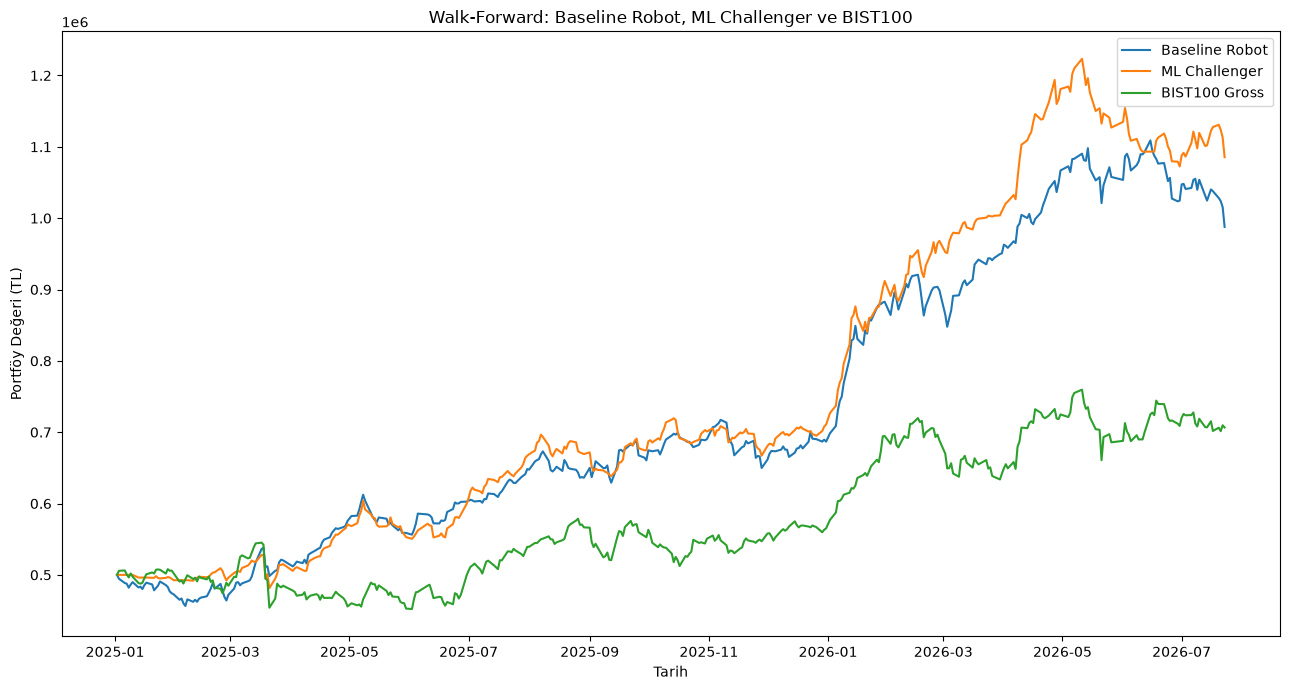

In [20]:
import matplotlib.pyplot as plt

chart = equity_comparison.set_index("Date")

plt.figure(figsize=(13, 7))
plt.plot(
    chart.index,
    chart["Baseline_Robot"],
    label="Baseline Robot",
)
plt.plot(
    chart.index,
    chart["ML_Challenger"],
    label="ML Challenger",
)
plt.plot(
    chart.index,
    chart["BIST100_Gross"],
    label="BIST100 Gross",
)
plt.title(
    "Walk-Forward: Baseline Robot, ML Challenger ve BIST100"
)
plt.xlabel("Tarih")
plt.ylabel("Portföy Değeri (TL)")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Sonuçları dashboard için kaydet


In [21]:
OUTPUT_DIR = (
    PROJECT_ROOT
    / "results"
    / "ml"
    / "walk_forward"
)

metadata = {
    "method": "Monthly expanding walk-forward",
    "start": WALK_FORWARD_START,
    "end": WALK_FORWARD_END,
    "retrain_frequency": (
        walk_forward_config.retrain_frequency
    ),
    "embargo_days": (
        walk_forward_config.embargo_days
    ),
    "target": deployment.target,
    "model": deployment.model_name,
    "filter": deployment.filter_name,
    "probability_threshold": (
        deployment.probability_threshold
    ),
    "feature_count": len(
        BASE_FEATURE_COLUMNS
    ),
    "selection_window": "2018-2024",
    "evaluation_window": "2025+",
    "warning": (
        "2025+ was previously inspected; this is a "
        "leakage-controlled audit, not a pristine holdout."
    ),
}

artifact_paths = save_walk_forward_artifacts(
    output_directory=OUTPUT_DIR,
    comparison_metrics=comparison_metrics,
    equity_comparison=equity_comparison,
    yearly_table=yearly_table,
    active_table=active_table,
    training_log=training_log,
    probability_prices=probability_prices,
    metadata=metadata,
)

for name, path in artifact_paths.items():
    print(name, "→", path)


metrics → c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\results\ml\walk_forward\walk_forward_comparison_metrics.csv
equity → c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\results\ml\walk_forward\walk_forward_equity.parquet
yearly → c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\results\ml\walk_forward\walk_forward_yearly.csv
active → c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\results\ml\walk_forward\walk_forward_active_metrics.csv
training_log → c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\results\ml\walk_forward\walk_forward_training_log.csv
probabilities → c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\results\ml\walk_forward\walk_forward_probabilities.parquet
metadata → c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\results\ml\walk_forward\walk_forward_metadata.json


In [22]:
import numpy as np
audit_features = featured_prices.loc[
    featured_prices["Date"].between(
        "2025-01-01",
        "2025-02-28",
    )
    & featured_prices["Signal"].eq("AL"),
    ["Date", "Ticker", *BASE_FEATURE_COLUMNS],
].copy()

records = []

for month, group in audit_features.groupby(
    audit_features["Date"].dt.to_period("M")
):
    missing_counts = (
        group[BASE_FEATURE_COLUMNS]
        .replace([np.inf, -np.inf], np.nan)
        .isna()
        .sum()
    )

    for feature, count in missing_counts[
        missing_counts.gt(0)
    ].items():
        records.append(
            {
                "Month": str(month),
                "Feature": feature,
                "Missing_Count": int(count),
                "Event_Count": len(group),
                "Missing_Rate_%": (
                    count / len(group) * 100
                ),
            }
        )

missing_feature_audit = (
    pd.DataFrame(records)
    .sort_values(
        ["Month", "Missing_Count"],
        ascending=[True, False],
    )
)

display(missing_feature_audit)

,Month,Feature,Missing_Count,Event_Count,Missing_Rate_%
1,2025-01,RET_20,15,296,5.067568
2,2025-01,VOLATILITY_20,15,296,5.067568
0,2025-01,RET_5,4,296,1.351351
3,2025-01,EMA20_SLOPE_5,4,296,1.351351
4,2025-01,EMA50_SLOPE_5,4,296,1.351351
5,2025-01,ADX_CHANGE_5,4,296,1.351351
6,2025-01,RSI_CHANGE_5,4,296,1.351351
7,2025-02,RET_20,5,153,3.267974
8,2025-02,VOLATILITY_20,5,153,3.267974


In [23]:
market_diagnostics = pd.DataFrame(
    [
        {
            "Dataset": "market_prices",
            "Start": market_prices["Date"].min(),
            "End": market_prices["Date"].max(),
            "Rows": len(market_prices),
        },
        {
            "Dataset": "market_features",
            "Start": market_features["Date"].min(),
            "End": market_features["Date"].max(),
            "Rows": len(market_features),
        },
        {
            "Dataset": "featured_prices MARKET_RET_63",
            "Start": featured_prices.loc[
                featured_prices["MARKET_RET_63"].notna(),
                "Date",
            ].min(),
            "End": featured_prices.loc[
                featured_prices["MARKET_RET_63"].notna(),
                "Date",
            ].max(),
            "Rows": featured_prices[
                "MARKET_RET_63"
            ].notna().sum(),
        },
    ]
)

display(market_diagnostics)

,Dataset,Start,End,Rows
0,market_prices,2018-01-02,2026-07-23,2131
1,market_features,2018-10-18,2026-07-23,1932
2,featured_prices MARKET_RET_63,2019-01-18,2026-07-23,147460
